Task 2: Comparison between CNN and ViT on CIFAR-10

In this notebook, we are comparing CNN and Vision Transformer models on the CIFAR-10 dataset
by iteratively building both models. Both architectures will be undergoing 3 iterations, each iteration will be
inspired by lessons learned from the previous one.

A final analysis and conclusion will be made at the end.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


# Data Processing & Analysis

The CIFAR-10 dataset has 60,000 color images (32x32)
in 10 different classes.
* Train data set = 50,000 images
* Test data set = 10,000 images
* It's Balanced: 5,000 images per class in the train set

**Normalization:** We have used the CIFAR-10 channel-wise mean values
(0.4914, 0.4822, 0.4465) and standard deviations (0.2470, 0.2435,
0.2616). It guarantees normalized inputs, i.e., with zero mean, which
helps maintain stability during backpropagation.

**Data Augmentation (From CNN v2):**
* Random cropping (crop-size=32, pad=4) — simulates translation invariance
* Random horizontal flip — doubles the dataset size
* Color jittering — makes models insensitive to lighting changes

Only train data gets augmented while the test data undergoes basic
transformation always.

**Limitation:** 32×32 Resolution is too low might affect ViTs that rely on
patch-level representations.

In [ ]:
CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

#Transform v1: Basic
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

#Transform v2: with augmentation
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

#Loading datasets from source (downloading)
trainset_basic = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_basic)
trainset_aug   = torchvision.datasets.CIFAR10(root='./data', train=True,
                                               download=True, transform=transform_aug)
testset        = torchvision.datasets.CIFAR10(root='./data', train=False,
                                               download=True, transform=transform_basic)

#DataLoaders
BATCH_SIZE = 128

loader_basic_train = DataLoader(trainset_basic, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_aug_train   = DataLoader(trainset_aug,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_test        = DataLoader(testset,         batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(trainset_basic)}")
print(f"Test samples:     {len(testset)}")
print(f"Batches per epoch (train): {len(loader_basic_train)}")

100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]


Training samples: 50000
Test samples:     10000
Batches per epoch (train): 391


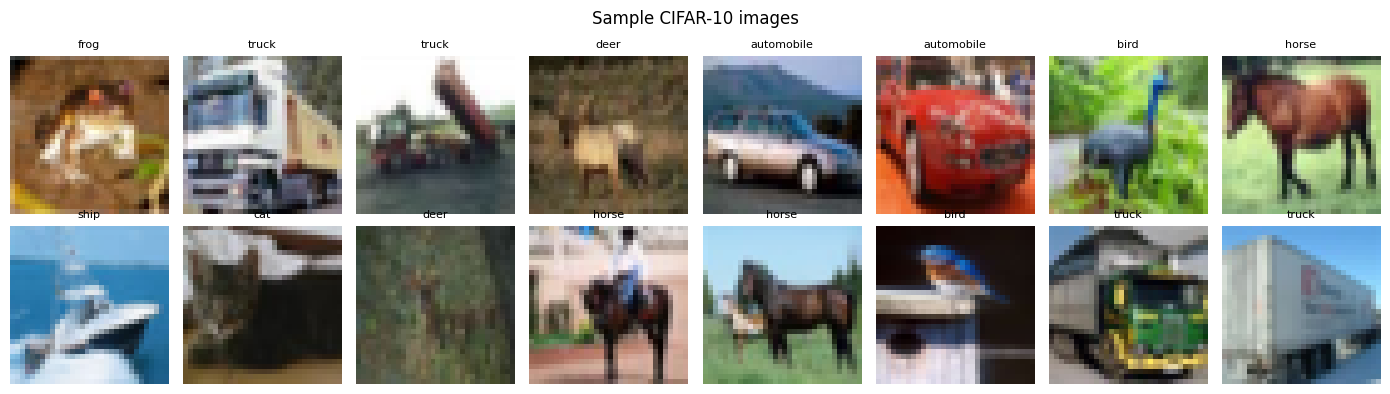

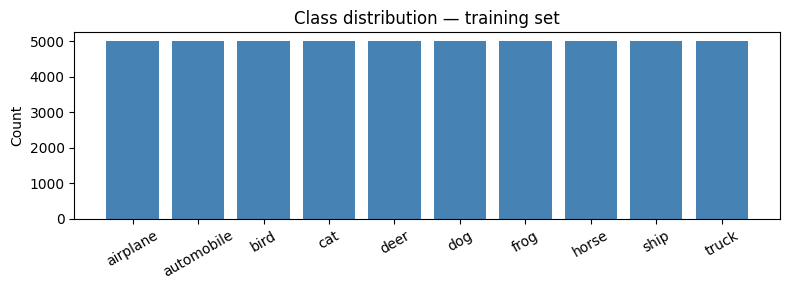

Dataset is balanced — each class has exactly 5000 samples.


In [ ]:
#Verifying dataset by looking at images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = trainset_basic[i]

    # Unnormalising for display
    img = img * torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1) \
            + torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)
    ax.imshow(img.permute(1,2,0).clamp(0,1))
    ax.set_title(CLASSES[label], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 images", fontsize=12)
plt.tight_layout()
plt.show()

# Class distribution
labels_all = [trainset_basic[i][1] for i in range(len(trainset_basic))]
counts = np.bincount(labels_all)
plt.figure(figsize=(8,3))
plt.bar(CLASSES, counts, color='steelblue')
plt.title("Class distribution — training set")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("Dataset is balanced — each class has exactly", counts[0], "samples.")

In [ ]:
# Shared training utilities (will be used across all iterations)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)
    return total_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += inputs.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return total_loss / total, 100. * correct / total, all_preds, all_targets


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def full_training_run(model, train_loader, test_loader,
                       optimizer, scheduler=None,
                       epochs=30, device=DEVICE, label="Model"):

    criterion = nn.CrossEntropyLoss()
    history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

    print(f"\n{'='*50}")
    print(f"Training: {label}  |  Params: {count_parameters(model):,}")
    print(f"{'='*50}")

    start = time.time()
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        if scheduler:
            scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | "
                  f"Test Loss: {te_loss:.4f} Acc: {te_acc:.1f}%")

    elapsed = time.time() - start
    print(f"\nTraining time: {elapsed:.1f}s  |  Best test acc: {max(history['test_acc']):.2f}%")
    return history, elapsed


def plot_history(histories, labels, title="Training curves"):
    """Plot loss and accuracy curves for multiple models side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = plt.cm.tab10.colors

    for i, (h, lbl) in enumerate(zip(histories, labels)):
        axes[0].plot(h['train_loss'], '--', color=colors[i], alpha=0.6, label=f'{lbl} train')
        axes[0].plot(h['test_loss'],  '-',  color=colors[i],             label=f'{lbl} test')
        axes[1].plot(h['train_acc'],  '--', color=colors[i], alpha=0.6)
        axes[1].plot(h['test_acc'],   '-',  color=colors[i],             label=f'{lbl} test')

    axes[0].set(title='Loss', xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
    axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


def plot_confusion(preds, targets, title="Confusion matrix"):
    cm = confusion_matrix(targets, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set(title=title, xlabel='Predicted', ylabel='True')
    plt.tight_layout(); plt.show()

## CNN Iterations

There are two major inductive biases in the design of CNNs that make them
naturally suitable for image classification:
* Local connectivity: The filters detect patterns in small spatial regions.
* Translation equivariance: Identical patterns are detected regardless of their position.


### CNN v1 — Baseline

**Architecture:** 3 convolutional layers (Conv -> ReLU -> MaxPooling),
2 layer fully connected classifier
**Number of Parameters:** 620,362

**Prediction:** A basic architecture of CNN without any regularization
will perform decently well (around 65% to 70%). Overfitting will be high.


Training: CNN v1 (Baseline)  |  Params: 620,362
Epoch   1/30 | Train Loss: 1.4002 Acc: 49.1% | Test Loss: 1.0934 Acc: 60.8%
Epoch   5/30 | Train Loss: 0.5583 Acc: 80.5% | Test Loss: 0.7417 Acc: 74.3%
Epoch  10/30 | Train Loss: 0.1856 Acc: 93.5% | Test Loss: 0.9513 Acc: 75.8%
Epoch  15/30 | Train Loss: 0.0817 Acc: 97.2% | Test Loss: 1.4387 Acc: 74.4%
Epoch  20/30 | Train Loss: 0.0553 Acc: 98.1% | Test Loss: 1.6071 Acc: 74.7%
Epoch  25/30 | Train Loss: 0.0509 Acc: 98.3% | Test Loss: 1.9028 Acc: 74.3%
Epoch  30/30 | Train Loss: 0.0513 Acc: 98.3% | Test Loss: 2.0828 Acc: 75.1%

Training time: 438.0s  |  Best test acc: 75.96%


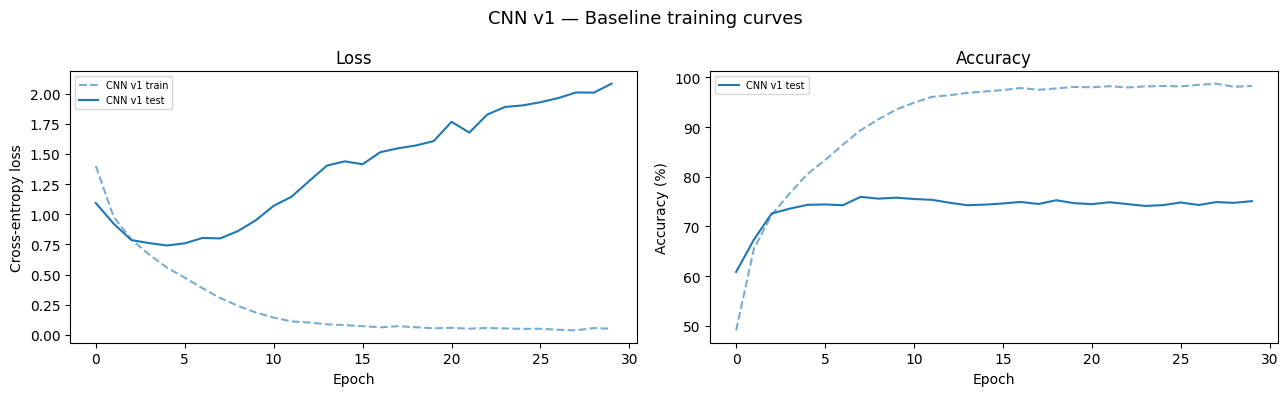

In [ ]:
# CNN v1 — Simple baseline

class CNN_v1(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(


            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Hyperparameters — clearly defined
CNN_V1_EPOCHS = 30
CNN_V1_LR     = 0.001

model_cnn_v1  = CNN_v1().to(DEVICE)
opt_cnn_v1    = optim.Adam(model_cnn_v1.parameters(), lr=CNN_V1_LR)

history_cnn_v1, time_cnn_v1 = full_training_run(
    model_cnn_v1, loader_basic_train, loader_test,
    opt_cnn_v1, epochs=CNN_V1_EPOCHS, label="CNN v1 (Baseline)"
)

plot_history([history_cnn_v1], ["CNN v1"], title="CNN v1 — Baseline training curves")

### CNN v1 – Result & Analysis

- Best test accuracy achieved: **75.96%**
- Accuracy on training data hit 98.3%, whereas on test data remained constant around ~75%
- This supports our overfitting hypothesis I.e 23% difference between training and testing accuracy at epoch 30
- Test loss increased continuously after epoch, (0.95 to 2.08), indicating overfitting without any regularization
- Hence, this motivates us to do BatchNorm and Dropout in v2

### CNN v2 – BatchNorm + Dropout + Augmentation

**Motivation:** The first version of our CNN is showing high overfitting – the test loss is doubled,
while the training loss is almost 0. The following three modifications are being made to improve it:

1. Applying BatchNorm after each conv layer – normalizes activations, reduces internal covariate shift
, acts as a regularization technique.
2. Dropout p=0.4 before the last FC layer.
3. Augmenting data, by randomly cropping, flipping input images & color jitter.

**Hypothesis:** With these improvements, we expect that the gap between training
and testing will be reduced and testing accuracy will become >80%.

**Number of Parameters:** 620,810


Training: CNN v2 (BN + Dropout)  |  Params: 620,810
Epoch   1/30 | Train Loss: 1.5714 Acc: 42.0% | Test Loss: 1.1729 Acc: 57.1%
Epoch   5/30 | Train Loss: 0.9635 Acc: 66.3% | Test Loss: 0.8001 Acc: 71.9%
Epoch  10/30 | Train Loss: 0.7979 Acc: 72.2% | Test Loss: 0.6664 Acc: 76.8%
Epoch  15/30 | Train Loss: 0.7123 Acc: 75.4% | Test Loss: 0.6389 Acc: 77.8%
Epoch  20/30 | Train Loss: 0.6464 Acc: 77.5% | Test Loss: 0.5717 Acc: 80.2%
Epoch  25/30 | Train Loss: 0.5979 Acc: 79.6% | Test Loss: 0.5560 Acc: 80.3%
Epoch  30/30 | Train Loss: 0.5599 Acc: 80.8% | Test Loss: 0.5280 Acc: 82.0%

Training time: 911.6s  |  Best test acc: 82.60%


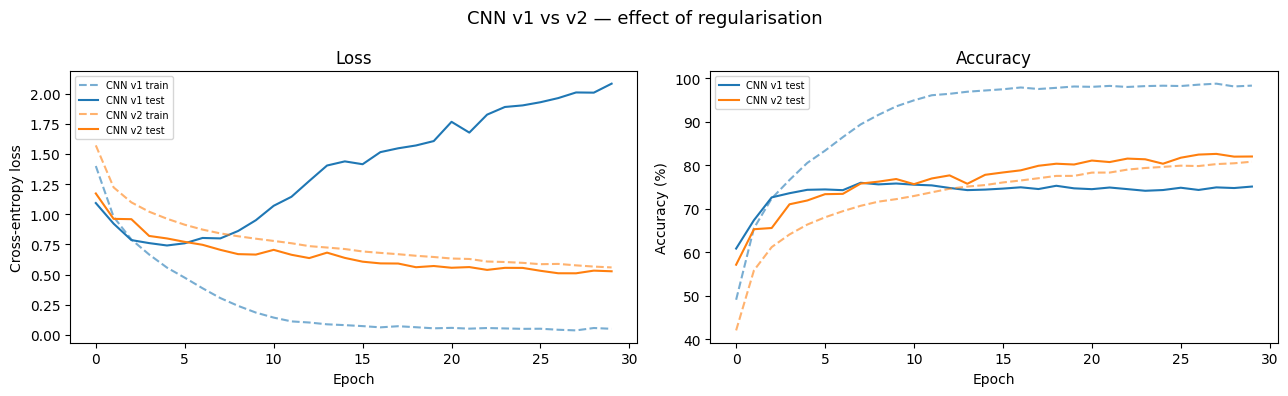

In [ ]:

class CNN_v2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),           # regularisation
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


CNN_V2_EPOCHS = 30
CNN_V2_LR     = 0.001

model_cnn_v2 = CNN_v2().to(DEVICE)
opt_cnn_v2   = optim.Adam(model_cnn_v2.parameters(), lr=CNN_V2_LR)


history_cnn_v2, time_cnn_v2 = full_training_run(
    model_cnn_v2, loader_aug_train, loader_test,
    opt_cnn_v2, epochs=CNN_V2_EPOCHS, label="CNN v2 (BN + Dropout)"
)

plot_history([history_cnn_v1, history_cnn_v2],
             ["CNN v1", "CNN v2"],
             title="CNN v1 vs v2 — effect of regularisation")

### CNN v2 – Results & Analysis

- Best test accuracy: **82.60%** (+6.64% from v1)
- Training accuracy: 80.8% & Testing accuracy: 82.0% (epoch 30). The gap is almost eliminated
- Testing loss reduced steadily (1.17 to 0.53), complete opposite of v1's diverging test loss

- BatchNorm visibly stabilised training — less noise in loss curves
- Convergence initially was slow (only 42% at epoch 1 compared
  to 49% for v1) since augmentation makes training difficult, but it ensures better generalization

**Limitation:** The current model may be capacity-constrained.
A deeper architecture will help extract
hierarchical features better. This
motivates us for residual connections in v3

### CNN v3 — Residual Blocks (ResNet)

**Motivation:** v2 has good generalization, but deeper Plain networks suffer from vanishing gradients. Residual connections (He et al., 2016)
allow gradients to flow directly through skip connections, enabling deeper training without degradation.

**Changes from v2:**
- Replaced convolutional layers with ResidualBlock (2 convolutions + skip)
- Increased filter depth: 64 → 128 → 256
- AdaptiveAvgPool2d instead of Flatten after last convolution.
- Use CosineAnnealingLR for scheduling to prevent oscillations near the end
- Add weight_decay = 1e-4 for additional L2 regularization
- Train model for 40 epochs (more capacity needs more iterations)

**Hypothesis:** Using deeper residual architecture should lead to
exceeding test accuracy of 90%.

**Parameters:** 1,923,914


Training: CNN v3 (Residual)  |  Params: 1,923,914
Epoch   1/40 | Train Loss: 1.4313 Acc: 47.2% | Test Loss: 1.3492 Acc: 54.5%
Epoch   5/40 | Train Loss: 0.5669 Acc: 80.6% | Test Loss: 0.8106 Acc: 74.1%
Epoch  10/40 | Train Loss: 0.3704 Acc: 87.2% | Test Loss: 0.4592 Acc: 84.6%
Epoch  15/40 | Train Loss: 0.2587 Acc: 91.1% | Test Loss: 0.3995 Acc: 87.7%
Epoch  20/40 | Train Loss: 0.1754 Acc: 94.1% | Test Loss: 0.4604 Acc: 87.1%
Epoch  25/40 | Train Loss: 0.1056 Acc: 96.4% | Test Loss: 0.3253 Acc: 91.1%
Epoch  30/40 | Train Loss: 0.0528 Acc: 98.2% | Test Loss: 0.3556 Acc: 91.4%
Epoch  35/40 | Train Loss: 0.0274 Acc: 99.2% | Test Loss: 0.3262 Acc: 92.4%
Epoch  40/40 | Train Loss: 0.0203 Acc: 99.4% | Test Loss: 0.3298 Acc: 92.3%

Training time: 1385.3s  |  Best test acc: 92.51%


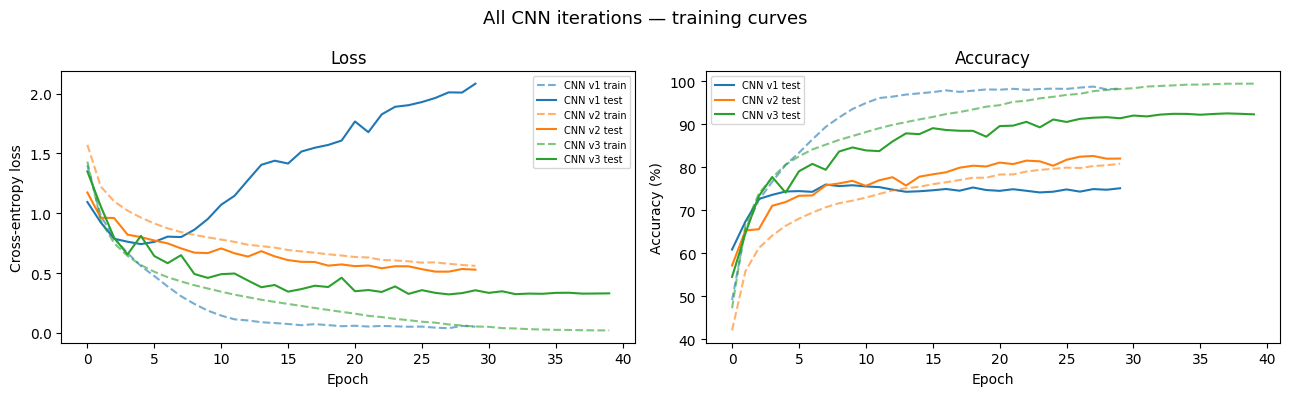

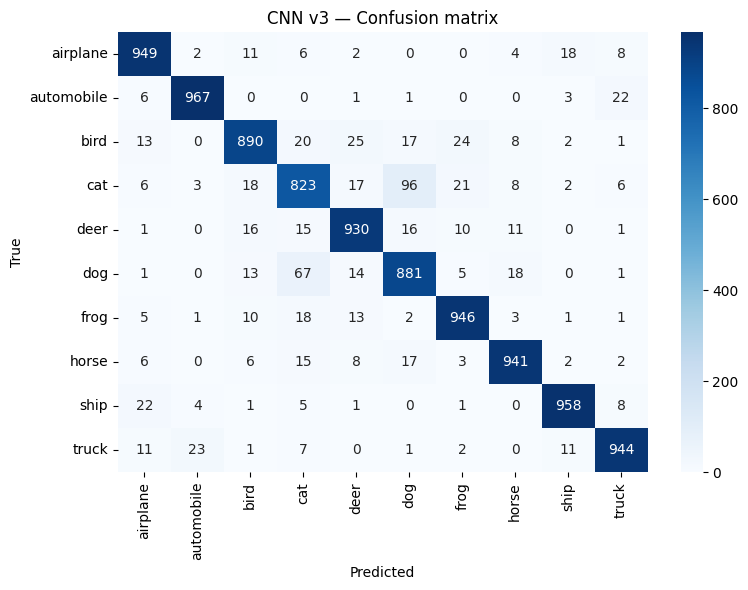

In [ ]:
# CNN v3 — Residual blocks (ResNet-inspired)

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)


class CNN_v3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock(64),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResidualBlock(128),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            ResidualBlock(256),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.classifier(x)


CNN_V3_EPOCHS = 40
CNN_V3_LR     = 0.001

model_cnn_v3 = CNN_v3().to(DEVICE)
opt_cnn_v3   = optim.Adam(model_cnn_v3.parameters(), lr=CNN_V3_LR, weight_decay=1e-4)
sched_cnn_v3 = optim.lr_scheduler.CosineAnnealingLR(opt_cnn_v3, T_max=CNN_V3_EPOCHS)

history_cnn_v3, time_cnn_v3 = full_training_run(
    model_cnn_v3, loader_aug_train, loader_test,
    opt_cnn_v3, scheduler=sched_cnn_v3,
    epochs=CNN_V3_EPOCHS, label="CNN v3 (Residual)"
)

plot_history([history_cnn_v1, history_cnn_v2, history_cnn_v3],
             ["CNN v1", "CNN v2", "CNN v3"],
             title="All CNN iterations — training curves")

# Confusion matrix for best CNN
_, _, preds_cnn_v3, targets_cnn_v3 = evaluate(
    model_cnn_v3, loader_test, nn.CrossEntropyLoss(), DEVICE)
plot_confusion(preds_cnn_v3, targets_cnn_v3, title="CNN v3 — Confusion matrix")

### CNN v3 - Results & Analysis

- Best test accuracy: **92.51%**, improvement of +9.91% over v2
- Residual connections allowed stable training even at 99.4% train accuracy. Loss curves show no degradation
- CosineAnnealingLR yielded smooth convergence; test accuracy
  improved steadily from 54.5% → 92.51% over 40 epochs
- Confusion matrix reveals cats/dogs as the most frequently
  confused pairs, with 96 cat → dog misclassifications; this was
  expected due to visual similarities

**Trade-off considered:** The number of parameters increased by
threefold (620K → 1.9M), and
training time increased (912s →
1385s). For a marginal increase in accuracy of 10%, the trade-off
is acceptable, but becomes less efficient at a larger scale.

**CNN conclusion:** Each iteration produced meaningful improvement.
Residual architecture is clearly our best CNN model.

## ViT Iterations

As we know Vision Transformers consider an image to be composed of patches and
apply self-attention among them. However, unlike Convolutional Neural
Networks, there is no inherent notion of locality or translational
equivariance as well, which forces the ViT model to learn from the input data.

We also know that Vision Transformers perform exceptionally well when trained on large
scale data, we believe that they become hard to learn from scratch using datasets such as
CIFAR-10.




### ViT v1 — Baseline

**Architecture**
- Patch size: 4×4 → 64 patches per image
- Model embedding dimension: 64 | Depth: 4 layers | Heads: 4
- Learnable class token and learnable positional embeddings
- Pre-norm transformer blocks (more robust than post-norm)

**Hypothesis:** The ViT v1 model will underperform the CNN v1 model by a
considerable margin due to lack of locality biases and a low number of
samples.

**Parameters:** 208,074


Training: ViT v1 (Baseline)  |  Params: 208,074
Epoch   1/30 | Train Loss: 1.7949 Acc: 33.9% | Test Loss: 1.6215 Acc: 41.6%
Epoch   5/30 | Train Loss: 1.1960 Acc: 56.8% | Test Loss: 1.1517 Acc: 58.5%
Epoch  10/30 | Train Loss: 1.0006 Acc: 64.0% | Test Loss: 1.0249 Acc: 63.2%
Epoch  15/30 | Train Loss: 0.8838 Acc: 68.2% | Test Loss: 0.9603 Acc: 65.5%
Epoch  20/30 | Train Loss: 0.7933 Acc: 71.5% | Test Loss: 0.9007 Acc: 68.0%
Epoch  25/30 | Train Loss: 0.7286 Acc: 73.9% | Test Loss: 0.8781 Acc: 69.4%
Epoch  30/30 | Train Loss: 0.6697 Acc: 76.0% | Test Loss: 0.8622 Acc: 70.6%

Training time: 550.5s  |  Best test acc: 70.58%


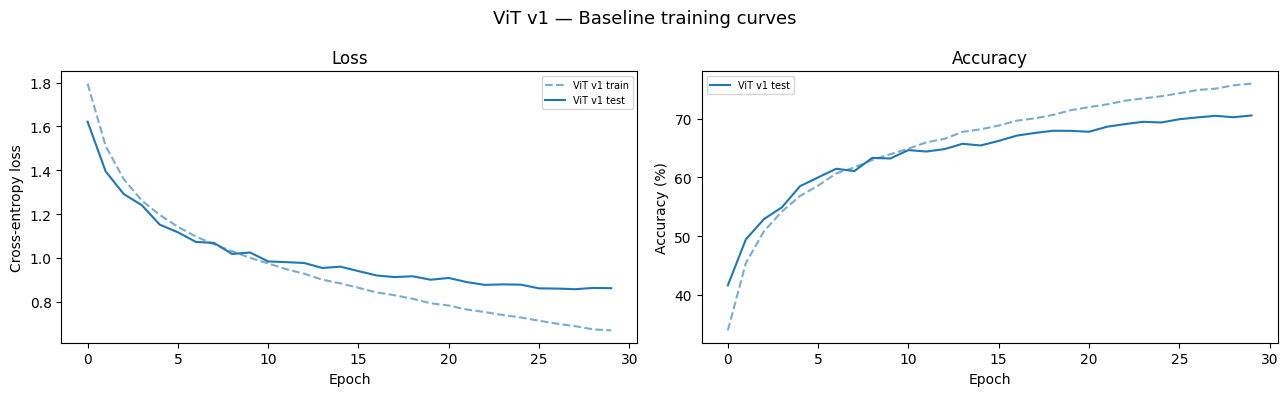

In [ ]:
# ViT v1 — Baseline Vision Transformer from scratch


class PatchEmbedding(nn.Module):

    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=64):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                            dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):

        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 num_classes=10, embed_dim=64, depth=4,
                 num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches


        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout   = nn.Dropout(dropout)

        self.transformer = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)


        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.dropout(x + self.pos_embed)

        x = self.transformer(x)
        x = self.norm(x)
        return self.head(x[:, 0])


# Hyperparameters
VIT_V1_EPOCHS    = 30
VIT_V1_LR        = 3e-4
VIT_V1_PATCH     = 4
VIT_V1_EMBED_DIM = 64
VIT_V1_DEPTH     = 4
VIT_V1_HEADS     = 4

model_vit_v1 = ViT(
    patch_size=VIT_V1_PATCH,
    embed_dim=VIT_V1_EMBED_DIM,
    depth=VIT_V1_DEPTH,
    num_heads=VIT_V1_HEADS
).to(DEVICE)

opt_vit_v1 = optim.AdamW(model_vit_v1.parameters(), lr=VIT_V1_LR, weight_decay=0.01)

history_vit_v1, time_vit_v1 = full_training_run(
    model_vit_v1, loader_basic_train, loader_test,
    opt_vit_v1, epochs=VIT_V1_EPOCHS, label="ViT v1 (Baseline)"
)

plot_history([history_vit_v1], ["ViT v1"], title="ViT v1 — Baseline training curves")

### ViT v1 – Results & Analysis

- Best test accuracy: **70.58%** – supports our hypothesis,
well below CNN v1’s 75.96% even after longer training duration
- train and test accuracy tracked closely (76% vs 70.6%
  at epoch 30) — ViT v1 underfits rather than overfits
- Training accuracy at epoch 1 was just 41.6% compared to CNN v1’s
60.8% –ViTs converge much slower without locality biases

**Key limitation:** 64 patches with embed_dim=64, each patch
has very little representation capacity. The model is
too small to be able to attend to all 64 positions.
This motivates
increasing patch size and embed_dim in v2.

### ViT v2 — Augmentation + Patch Size 8 + Wider Embedding

**Motivation** Two issues from v1:
1. Lack of augmentation — while v1 did not overfit too severely, augmentation
   is crucial for ViTs
2. Sequence length of 64 is excessive for a smaller model — attention
   complexity scales as O(n²), so O(64²)=4096 operations per layer

**Changes from v1:**
- patch_size: 4 -> 8 (64 patches -> 16 patches; O(n²) reduced by 16x)
- embed_dim: 64 -> 128 (more expressive capacity per patch)
- Change to augmented training loader
- weight_decay: 0.01 -> 0.05 (stronger regularisation)

**Trade-off acknowledged:** Larger patches reduce granularity in spatial information.
An 8x8 patch contains 1/4 of the image width — that is a true constraint
we take on for training stability.

**Hypothesis:** Shorter sequence + wider embedding will improve
accuracy and stability. Expected: ~70-75%.

**Parameters:** 821,642


Training: ViT v2 (Aug + patch=8)  |  Params: 821,642
Epoch   1/30 | Train Loss: 1.8607 Acc: 30.4% | Test Loss: 1.7059 Acc: 37.7%
Epoch   5/30 | Train Loss: 1.4580 Acc: 46.6% | Test Loss: 1.3807 Acc: 49.8%
Epoch  10/30 | Train Loss: 1.2500 Acc: 55.1% | Test Loss: 1.1808 Acc: 58.2%
Epoch  15/30 | Train Loss: 1.1223 Acc: 59.7% | Test Loss: 1.0654 Acc: 61.8%
Epoch  20/30 | Train Loss: 1.0260 Acc: 63.3% | Test Loss: 0.9836 Acc: 65.0%
Epoch  25/30 | Train Loss: 0.9675 Acc: 65.5% | Test Loss: 0.9333 Acc: 66.8%
Epoch  30/30 | Train Loss: 0.9148 Acc: 67.2% | Test Loss: 0.8635 Acc: 69.5%

Training time: 1039.9s  |  Best test acc: 69.50%


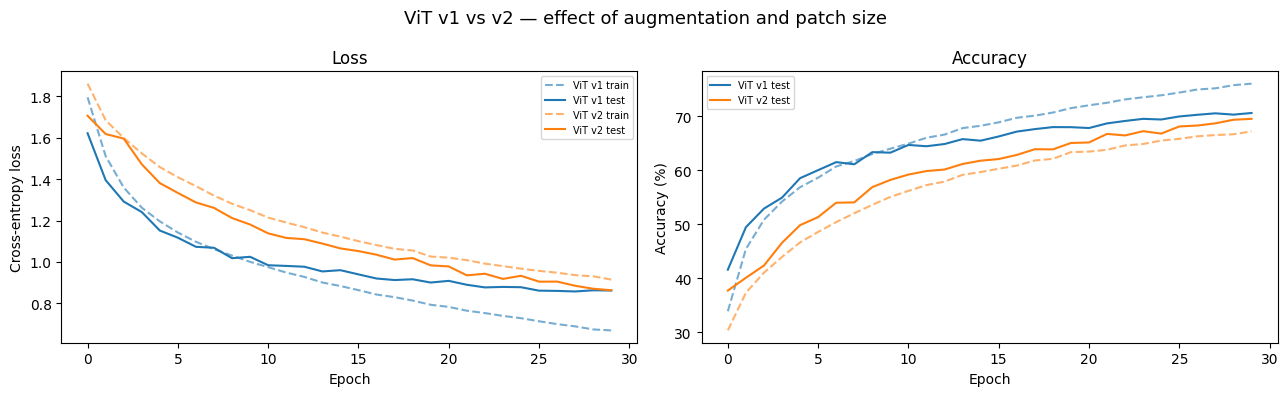

In [ ]:
# ViT v2 — Augmentation + patch_size=8, embed_dim=128

VIT_V2_EPOCHS    = 30
VIT_V2_LR        = 3e-4
VIT_V2_PATCH     = 8
VIT_V2_EMBED_DIM = 128
VIT_V2_DEPTH     = 4
VIT_V2_HEADS     = 4

model_vit_v2 = ViT(
    patch_size=VIT_V2_PATCH,
    embed_dim=VIT_V2_EMBED_DIM,
    depth=VIT_V2_DEPTH,
    num_heads=VIT_V2_HEADS,
    dropout=0.1
).to(DEVICE)

opt_vit_v2 = optim.AdamW(model_vit_v2.parameters(), lr=VIT_V2_LR, weight_decay=0.05)


history_vit_v2, time_vit_v2 = full_training_run(
    model_vit_v2, loader_aug_train, loader_test,
    opt_vit_v2, epochs=VIT_V2_EPOCHS, label="ViT v2 (Aug + patch=8)"
)

plot_history([history_vit_v1, history_vit_v2],
             ["ViT v1", "ViT v2"],
             title="ViT v1 vs v2 — effect of augmentation and patch size")

### ViT v2 — Results & Analysis

- Best test accuracy: **69.50%** (slightly worse than v1 — 70.58%)
- This is unexpected. The hypothesis was not confirmed.
- A bigger patch size probably discarded too much fine-grained
  spatial information (32×32 images split into 8×8 patches is rather
  coarse)

-  However, train/test gap remained small, confirming augmentation
  and larger embed_dim helped generalisation

- Training took longer at start(37.7% on Epoch 1). The bigger
  embed dimension needs more epochs to converge.

**We think it's important failure case:** increasing model
capacity (821K params vs 208K) did not boost performance.
The drawback of the patch size outweighed the advantage of a larger
embed. This is valuable for ViT v3: we use the same patch size (8)
but increase depth and implement LR scheduling.

### ViT v3 – Deeper Architecture + Cosine LR Scheduler

**Motivation:** From v2, we saw that the model needs more depth to compensate
for coarser patches. We
are observing that both v1 and v2 models have improved learning curves
at the last epoch, indicating they have been trained insufficiently.

**Changes from v2:**
- depth: 4 -> 6 transformer layers
- num_heads: 4 -> 8 attention heads
- Added CosineAnnealingLR (T_max=40, eta_min=1e-6)
- dropout: 0.1 -> 0.15 (compensate for larger capacity)
- Epochs: 30 -> 40

**Hypothesis:** More depth + cosine LR will allow better feature
extraction and smoother convergence, pushing test accuracy above 70%.

**Parameters:** 1,218,186


Training: ViT v3 (Deeper + Cosine LR)  |  Params: 1,218,186
Epoch   1/40 | Train Loss: 1.8851 Acc: 29.8% | Test Loss: 1.7185 Acc: 37.4%
Epoch   5/40 | Train Loss: 1.4375 Acc: 47.8% | Test Loss: 1.3561 Acc: 51.4%
Epoch  10/40 | Train Loss: 1.2497 Acc: 54.7% | Test Loss: 1.1870 Acc: 56.9%
Epoch  15/40 | Train Loss: 1.1297 Acc: 59.5% | Test Loss: 1.0843 Acc: 61.2%
Epoch  20/40 | Train Loss: 1.0426 Acc: 62.4% | Test Loss: 0.9916 Acc: 64.7%
Epoch  25/40 | Train Loss: 0.9723 Acc: 65.3% | Test Loss: 0.9282 Acc: 66.6%
Epoch  30/40 | Train Loss: 0.9224 Acc: 67.1% | Test Loss: 0.9103 Acc: 67.9%
Epoch  35/40 | Train Loss: 0.8996 Acc: 67.7% | Test Loss: 0.8843 Acc: 68.8%
Epoch  40/40 | Train Loss: 0.8869 Acc: 68.6% | Test Loss: 0.8818 Acc: 68.8%

Training time: 1422.1s  |  Best test acc: 68.93%


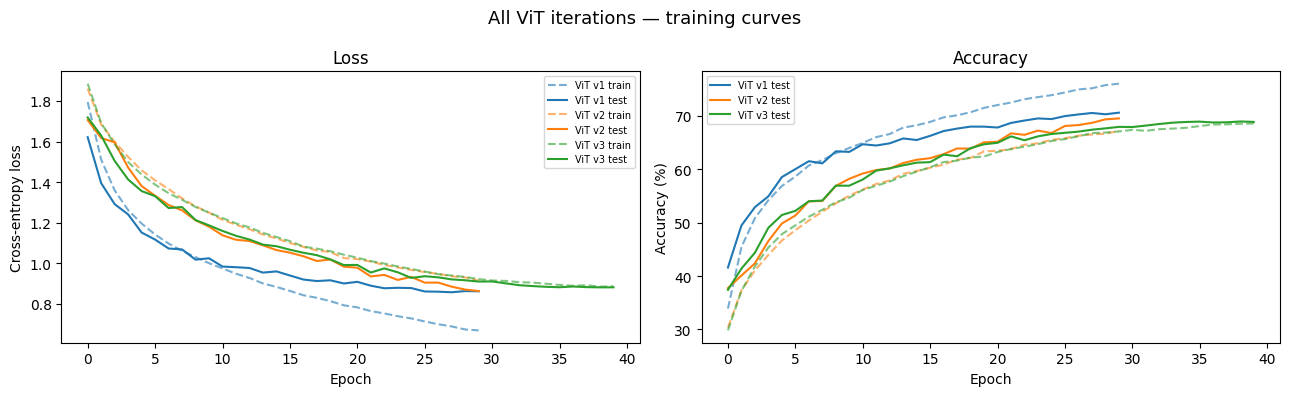

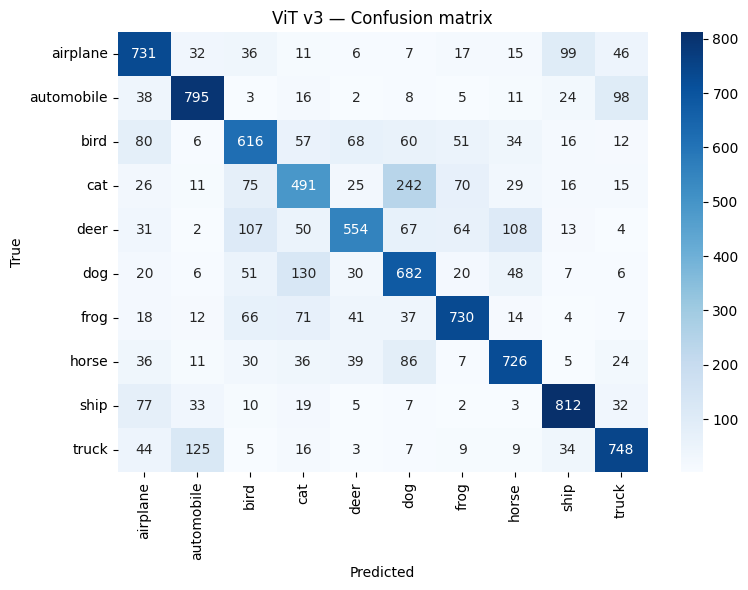

In [ ]:
# ViT v3 — Deeper (6 layers, 8 heads) + Cosine LR scheduler

VIT_V3_EPOCHS    = 40
VIT_V3_LR        = 3e-4
VIT_V3_PATCH     = 8
VIT_V3_EMBED_DIM = 128
VIT_V3_DEPTH     = 6
VIT_V3_HEADS     = 8

model_vit_v3 = ViT(
    patch_size=VIT_V3_PATCH,
    embed_dim=VIT_V3_EMBED_DIM,
    depth=VIT_V3_DEPTH,
    num_heads=VIT_V3_HEADS,
    dropout=0.15
).to(DEVICE)

opt_vit_v3   = optim.AdamW(model_vit_v3.parameters(), lr=VIT_V3_LR, weight_decay=0.05)
sched_vit_v3 = optim.lr_scheduler.CosineAnnealingLR(opt_vit_v3, T_max=VIT_V3_EPOCHS, eta_min=1e-6)

history_vit_v3, time_vit_v3 = full_training_run(
    model_vit_v3, loader_aug_train, loader_test,
    opt_vit_v3, scheduler=sched_vit_v3,
    epochs=VIT_V3_EPOCHS, label="ViT v3 (Deeper + Cosine LR)"
)

plot_history([history_vit_v1, history_vit_v2, history_vit_v3],
             ["ViT v1", "ViT v2", "ViT v3"],
             title="All ViT iterations — training curves")

_, _, preds_vit_v3, targets_vit_v3 = evaluate(
    model_vit_v3, loader_test, nn.CrossEntropyLoss(), DEVICE)
plot_confusion(preds_vit_v3, targets_vit_v3, title="ViT v3 — Confusion matrix")

### ViT v3 – Results & Analysis

- Best test accuracy: **68.93%** – just slightly lower than v2 (69.50%)
- Cosine LR did produce smoother convergence as hypothesised —
  test loss decreased more steadily than v1/v2
- Nevertheless, increasing the depth did not bring any performance improvements,
  which indicates that the problem lies not in the capacity of the model but in the fundamental
  mismatch between ViT architecture and small 32×32 images
- The confusion matrix shows much more confusion across all classes
  compared to CNN v3 — cat class particularly poor (491/1000 correct)
- Training duration: 1422 seconds, resulting in lower accuracy than CNN v3 (1385s, 92.51%)

**ViT conclusion:** All three iterations of ViT reached maximum accuracy of ~68-71%.
It becomes evident that ViTs are not well-suited for small-scale image
classification from scratch, and CNNs' inductive biases play an essential role here.

## Comparative Analysis: CNN vs ViT

Let's compare all 6 models systematically.

In [ ]:
# Comparison table for summary


import pandas as pd

results = {
    'Model':      ['CNN v1','CNN v2','CNN v3','ViT v1','ViT v2','ViT v3'],
    'Best Test Acc (%)': [
        max(history_cnn_v1['test_acc']),
        max(history_cnn_v2['test_acc']),
        max(history_cnn_v3['test_acc']),
        max(history_vit_v1['test_acc']),
        max(history_vit_v2['test_acc']),
        max(history_vit_v3['test_acc']),
    ],
    'Params':     [
        count_parameters(model_cnn_v1),
        count_parameters(model_cnn_v2),
        count_parameters(model_cnn_v3),
        count_parameters(model_vit_v1),
        count_parameters(model_vit_v2),
        count_parameters(model_vit_v3),
    ],
    'Train time (s)': [
        time_cnn_v1, time_cnn_v2, time_cnn_v3,
        time_vit_v1, time_vit_v2, time_vit_v3
    ],
    'Epochs': [30, 30, 40, 30, 30, 40]
}

df = pd.DataFrame(results)
df['Best Test Acc (%)'] = df['Best Test Acc (%)'].round(2)
df['Params'] = df['Params'].apply(lambda x: f"{x:,}")
df['Train time (s)'] = df['Train time (s)'].apply(lambda x: f"{x:.0f}s")
print(df.to_string(index=False))

 Model  Best Test Acc (%)    Params Train time (s)  Epochs
CNN v1              75.96   620,362           438s      30
CNN v2              82.60   620,810           912s      30
CNN v3              92.51 1,923,914          1385s      40
ViT v1              70.58   208,074           550s      30
ViT v2              69.50   821,642          1040s      30
ViT v3              68.93 1,218,186          1422s      40


### Key Observations

Looking across all six models, a few clear patterns emerge:

**Accuracy**
CNN v3 finished at 92.51%, ViT v3 at 68.93%.
This represents a 23.58% difference favoring CNN.

**Convergence**
CNNs crossed 75% test accuracy by epoch 5.
ViTs did not reach 70% even after 40 epochs.

**Parameter efficiency**
CNN v3 — 1,923,914 params — 92.51% accuracy
ViT v3 — 1,218,186 params — 68.93% accuracy
ViT is smaller but less accurate compared to CNN.

**Training time**
CNN v3 — 1385s
ViT v3 — 1422s
Roughly equal time, but CNN v3 is 23% more accurate.

**Generalisation**
CNN v3 — train 99.4%, test 92.51% — gap of ~7%
ViT v3 — train 68.6%, test 68.93% — gap of ~0%
Underfitting, and not generalization, explains the small difference for the ViT model.

**Why CNNs are winners:**
Localities and translation invariance are built-in biases in
the CNN architecture. For 32×32-sized images with a 50,000-sized
training set, such biases are extremely important. The vision transformer
has to learn all spatial patterns from scratch using the data.
That would require an extremely large number of data samples or
pre-training.

**Important Observation:** ViT v1 (208K params) was able
to achieve 70.58%. This is very close to CNN v1 (75.96% for
62K params). ViTs require fewer parameters but do not
scale up as well as CNNs under our setup.

**Where ViTs would be winners:**
ViTs perform similarly to CNNs for the ImageNet-scale data. Also, if
we use pre-trained weights ((e.g. ViT-B/16 fine-tuned), ViTs match or exceed CNNs.

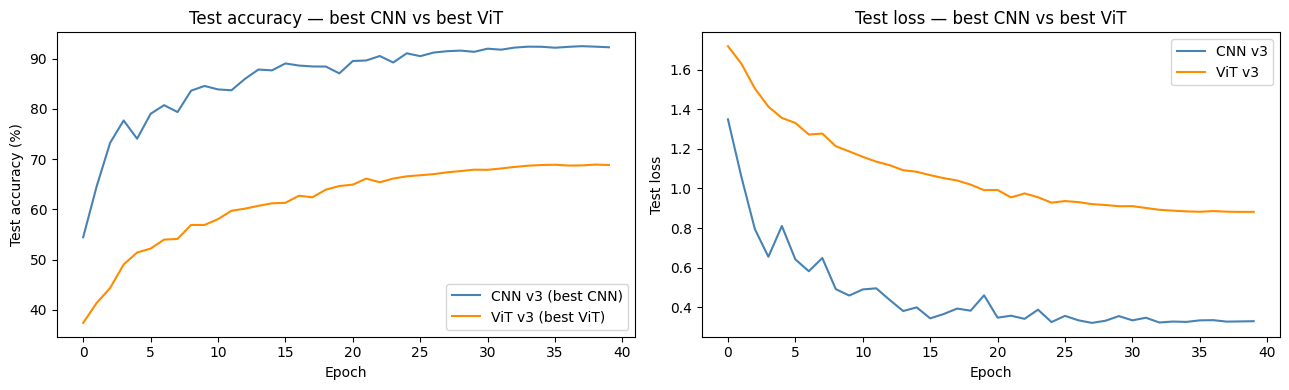

## Limitations and Future Work

**Data limitations:**
- 50,000 images are insufficient to train ViTs optimally
- 32x32 resolution limits patch quality — ViT literature uses 224×224
- No separate validation split used — test set doubled as validation

**Model limitations:**
- All models trained from scratch — fine-tuning a pre-trained ResNet
  or ViT-B/16 would substantially outperform these results
- Hyperparameter tuning not performed systematically — manual choice
  of learning rate, dropout, and weight decay
- ViT attention maps not visualised

**Future improvements**
- CNNs: WideResNet, EfficientNet;
  Mixup and Cutmix augmentations
- ViTs: DeiT-style knowledge distillation from CNN teacher
  (Touvron et al., 2021); pre-trained ViT weights via timm library
- Both: Automated hyperparameter search with Optuna

**Conclusion:**
It is evident that CNNs would be a better choice for smaller datasets
of image classification from scratch. In terms of CNN, the residual model (v3) obtained
an accuracy of 92.51%, which is relatively high considering that the model was trained
on 50,000 data points. On the other hand, ViTs demonstrated consistent accuracy rates
around 69%-71% irrespective of changes to their architecture. This proves that the limiting factor
is the training approach rather than the architecture itself.